# Data summary

Read in all the datasets and report various metrics.


In [2]:
! pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)


In [10]:
import pandas as pd

# Read in the folder
data_dir = '../manuscript/EnzEngDB_V2/experiments/'
meta_data = pd.read_excel('../manuscript/EnzEngDB_V2/meta_data.xlsx')
meta_data

,prefix,experiment_id,experiment_name,experiment_date,substrate_smiles,product_smiles,assay_technique,parent_amino_acid,cif_filename,doi,num_proteins,num_rows,num_fitness_entries,num_rxns,additional_information
0,LLMDB,exp_LLM27,A Diverse Library of Chiral Cyclopropane Scaff...,10/2/21,[N+](=[N-])=CC(CC1=CC=CC=C1)=O.C(=C)C1=CC=CC=C1,C1(=CC=CC=C1)CC(=O)[C@@H]1[C@H](C1)C1=CC=CC=C1,Spectroscopic Readout,VLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDRF...,chai52_0.cif,10.1021/jacs.0c09504,4,34,26,30,reaction_condition: reaction_temperature:room ...
1,LLMDB,exp_LLM79,A Photoenzymatic Strategy for Radical-Mediated...,12/27/22,CC(=C)C1=CC=CC=C1.[N+](=[N-])=CC(=O)OCC1=CC=CC=C1,C1(=CC=CC=C1)[C@H](CCC(=O)OCC1=CC=CC=C1)C,Mass Spectometry,MSFVKDFKPQALGDTNLFKPIKIGNNELLHRAVIPPLTRMRALHPG...,chai42_0.cif,10.1002/anie.202214135,7,22,19,15,reaction_condition: reaction_temperature:room ...
2,LLMDB,exp_LLM19,A cell-penetrating artificial metalloenzyme re...,4/24/18,NaN,N[C@@H](CC1=CC(I)=C(C(I)=C1)OC1=CC(I)=C(C=C1)O...,Spectroscopic Readout,MASMTGGQQMGRDQAGITGTWYNQLGSTFIVTAGADGALTGTYESA...,chai3_0.cif,10.1038/s41467-018-04440-0,18,22,8,1,reaction_condition: reaction_temperature:37 °C...
3,LLMDB,exp_LLM76,A designer enzyme for hydrazone and oxime form...,2/7/18,N(N)C1=CC=C(C2=NON=C21)[N+](=O)[O-].[N+](=O)([...,[N+](=O)([O-])C1=CC=C(C=2C1=NON2)NN=CC2=CC=C(C...,Spectroscopic Readout,GAEIPKEMLRAQTNVILLNVLKQGDNYVYGIIKQVKEASNGEMELN...,chai9_0.cif,10.1038/s41557-018-0082-z,3,3,3,1,reaction_condition: reaction_temperature:25 °C...
4,LLMDB,exp_LLM13,Accessing non-natural reactivity by irradiatin...,10/14/16,BrC1(CCCOC1=O)c2ccccc2,O=C1OC=CCC1c2ccccc2.O=C1OCCCC1c2ccccc2,Spectroscopic Readout,MTDRLKGKVAIVTGGTLGIGLAIADKFVEEGAKVVITGRHADVGEK...,chai66_0.cif,10.1038/nature20569,3,12,11,10,reaction_condition: reaction_temperature:25°C;...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,DMSDB,TrpB_3D,A combinatorially complete epistatic fitness l...,10/22/24,N[C@@H](CO)C(O)=O.C12=C(NC=C2)C=CC=C1,N[C@@H](CC3=CNC4=C3C=CC=C4)C(O)=O,Mass Spectometry,MKGYFGPYGGQYVPEILMGALEELEAAYEGIMKDESFWKEFNDLLR...,TrpB_3D.cif,10.5281/zenodo.15203754,8968,8969,8969,1,reaction_string: C=CC1=CC=CC=C1C.O=C(OCC)C=[N+...
172,DMSDB,T7,Evaluation of Machine Learning-Assisted Direct...,10/22/24,OCC1OC(COP(O)(O)=O)(C(C1O[*:1])O)O.OCC2OC(COP(...,OCC3OC(COP(O)(OCC4OC(C(C4O[*:2])O)O)=O)(C(C3O[...,Mass Spectometry,MNTINIAKNDFSDIELAAIPFNTLADHYGERLAREQLALEHESYEM...,T7.cif,10.5281/zenodo.15203754,6725,6726,430,1,reaction_string: C=CC1=CC=CC=C1C.O=C(OCC)C=[N+...
173,DMSDB,TrpB_B4,A combinatorially complete epistatic fitness l...,10/22/24,N[C@@H](CO)C(O)=O.C12=C(NC=C2)C=CC=C1,N[C@@H](CC3=CNC4=C3C=CC=C4)C(O)=O,Mass Spectometry,MKGYFGPYGGQYVPEILMGALEELEAAYEGIMKDESFWKEFNDLLR...,TrpB_B4.cif,10.5281/zenodo.15203754,193170,193171,193171,1,reaction_string: C=CC1=CC=CC=C1C.O=C(OCC)C=[N+...
174,DMSDB,TEV,Evaluation of Machine Learning-Assisted Direct...,10/22/24,[*:1]C(N[C@@H](C(N[C@@H](C([*:2])=O)[*:4])=O)[...,[*:1]C(N[C@@H](C(O)=O)[*:3])=O.N[C@@H](C([*:2]...,Mass Spectometry,GESLFKGPRDYNPISSTICHLTNESDGHTTSLYGIGFGPFIITNKH...,TEV.cif,10.5281/zenodo.15203754,159132,159133,158325,1,reaction_condition: reaction_temperature:room ...


# QC to ensure everything is correct

1. Ensure that all experiments have a #PARENT# enzyme sequence
2. Ensure all enzymes have a smiles string (for a product at least)
3. Ensure all enzymes have a fitness value (or set to be trace 0.001)
4. Plot all smiles strings to just get an overview of the diversity of the data

In [32]:
# Read in each of the experiments and write in how many entries are in there
from tqdm import tqdm 

num_proteins, num_rows, num_fit, num_rxns = [], [], [], []
df = meta_data
all_df = pd.DataFrame()
for prefix, exp in tqdm(df[['prefix', 'experiment_id']].values):
    exp_df = pd.read_csv(f'../manuscript/EnzEngDB_V2/experiments/{exp}.csv')
    exp_df['prefix'] = prefix
    exp_df = exp_df.dropna(subset='fitness_value')
    unique_proteins = len(set(list(exp_df['aa_sequence'].values)))
    unique_reactions = len(set(list(exp_df['smiles_string'].values)))
    unique_fitness = len(set(list(exp_df['fitness_value'].values)))
    # Check it has a parent value and this matches the parent value in the metadata file
    
    num_proteins.append(unique_proteins)
    num_rows.append(len(exp_df))
    num_fit.append(unique_fitness)
    num_rxns.append(unique_reactions)
    all_df = pd.concat([all_df, exp_df])

df['num_proteins'] = num_proteins
df['num_rows'] = num_rows
df['num_fitness_entries'] = num_fit
df['num_rxns'] = num_rxns

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 176/176 [00:05<00:00, 31.66it/s]


# Make the stats on the dataset based on each of the subsets (ARNLD, LLMDB and DMSDB)


In [33]:
from sciutil import SciUtil 

u = SciUtil()

gold_db = df[df['prefix'] == 'ARNLD']
u.dp(['ARNLD', f'num_proteins {gold_db["num_proteins"].sum()}',  
     f'num_fitness_entries {gold_db["num_fitness_entries"].sum()}', 
     f'num_rxns {gold_db["num_rxns"].sum()}', 
     f'num_rows {gold_db["num_rows"].sum()}'])

gold_db = df[df['prefix'] == 'LLMDB']
u.dp(['LLMDB', f'num_proteins {gold_db["num_proteins"].sum()}',  
     f'num_fitness_entries {gold_db["num_fitness_entries"].sum()}', 
     f'num_rxns {gold_db["num_rxns"].sum()}', 
     f'num_rows {gold_db["num_rows"].sum()}'])

gold_db = df[df['prefix'] == 'DMSDB']
u.dp(['DMSDB', f'num_proteins {gold_db["num_proteins"].sum()}',  
     f'num_fitness_entries {gold_db["num_fitness_entries"].sum()}', 
     f'num_rxns {gold_db["num_rxns"].sum()}', 
     f'num_rows {gold_db["num_rows"].sum()}'])

--------------------------------------------------------------------------------
  ARNLD	num_proteins 5021	num_fitness_entries 6049	num_rxns 649	num_rows 6415	  
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
  LLMDB	num_proteins 944	num_fitness_entries 1796	num_rxns 1087	num_rows 2415	  
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
DMSDB	num_proteins 449722	num_fitness_entries 442420	num_rxns 15	num_rows 449745	
--------------------------------------------------------------------------------


# Look through each of these in terms of the whole experiment file to find any outliers. 

In [34]:
all_df.columns

Index(['id', 'barcode_plate', 'plate', 'well', 'amino_acid_substitutions',
       'alignment_count', 'alignment_probability',
       'average_mutation_frequency', 'p_value', 'p_adj_value', 'nt_sequence',
       'aa_sequence', 'smiles_string', 'fitness_value', 'smiles_reaction',
       'fitness_type', 'reaction_condition', 'ttn', 'yield', 'ton', 'tof',
       'ee', 'selectivity', 'prefix', 'conversion', 'reaction_smiles',
       'enzyme_form', 'substrate_concentration',
       'activity_for_reaction_% (if applicable)', 'TTN (if applicable)',
       'selectivity(ee%),diastereo or chemo should be a separate smiles entry',
       'barcode_well', 'name', 'refseq', 'variant', 'index', 'barcode',
       'mixed_well', 'nucleotide_mutation', 'average_error_rate',
       'p_adj._value', 'row', 'column', 'sample_acq_order_no',
       'sample_vial_number', 'sample_name', 'compound_name', 'rt_[min]',
       'function_well', 'function_barcode_plate', 'filename',
       'additional_information'],
   

(array([9.47100e+03, 4.29500e+03, 1.59447e+05, 2.77127e+05, 2.46000e+02,
        2.42000e+02, 6.19000e+02, 9.00000e+00, 6.73500e+03, 3.84000e+02]),
 array([   5. ,  110.3,  215.6,  320.9,  426.2,  531.5,  636.8,  742.1,
         847.4,  952.7, 1058. ]),
 <BarContainer object of 10 artists>)

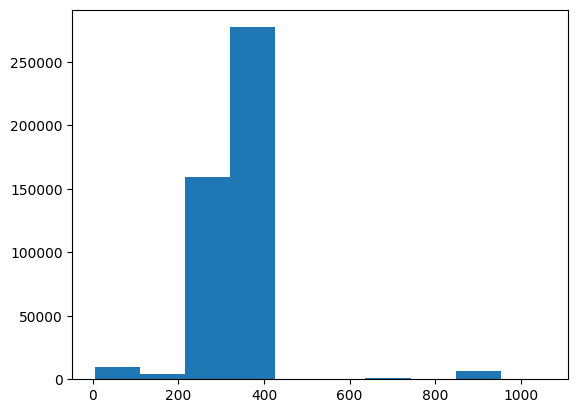

In [35]:
import matplotlib.pyplot as plt

all_df['SeqLen'] = [len(seq) for seq in all_df['aa_sequence'].values]
plt.hist(all_df['SeqLen'].values)

# Looked at low sequences, they are ones that don't have any calls from LevSeq often
```
#DEL#
#INS#
#N.A.#

```



In [38]:
all_df = all_df[~all_df['aa_sequence'].isin(['#DEL#', '#INS#', '#N.A.#'])]
gold_db = all_df[all_df['prefix'] == 'ARNLD']
llm_db = all_df[all_df['prefix'] == 'LLMDB']
dmsdb_db = all_df[all_df['prefix'] == 'DMSDB']


# Check the sequence length stats for each of these and also look at unique reactions etc for each one

In [42]:
for db in ['ARNLD', 'LLMDB', 'DMSDB']:
    df = all_df[all_df['prefix'] == db]

    seq_lengths = [len(seq) for seq in df['aa_sequence'].values]
    print(f"\n{db} Sequence length statistics:")
    print(f"  Mean: {np.mean(seq_lengths):.1f}")
    print(f"  Median: {np.median(seq_lengths):.1f}")
    print(f"  Min: {np.min(seq_lengths)}")
    print(f"  Max: {np.max(seq_lengths)}")
    print(f"  Std: {np.std(seq_lengths):.1f}")

    # For each check the reactions are 


ARNLD Sequence length statistics:
  Mean: 349.9
  Median: 388.0
  Min: 127
  Max: 1049
  Std: 208.3

LLMDB Sequence length statistics:
  Mean: 328.7
  Median: 273.0
  Min: 80
  Max: 1058
  Std: 227.0

DMSDB Sequence length statistics:
  Mean: 336.2
  Median: 390.0
  Min: 73
  Max: 883
  Std: 106.1


# Here we want to just report some statistics about the dataset

1. Number of data points in the GOLD standard dataset
2. Number of data points in the LLM dataset
3. Number of data points in the large datasets
4. Sequence length distribution
5. Pairwise similarity of the reactions

In [13]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs

# 1-3. Count data points by dataset type using the 'prefix' column
gold_count = df[df['prefix'] == 'ARNLD']['num_rows'].sum()
llm_count = df[df['prefix'] == 'LLMDB']['num_rows'].sum()
large_count = df[df['prefix'] == 'DMSDB']['num_rows'].sum()

print(f"GOLD standard dataset (ARNLD): {gold_count} data points")
print(f"LLM dataset (LLMDB): {llm_count} data points")
print(f"Large datasets (DMSDB): {large_count} data points")
print(f"Total: {gold_count + llm_count + large_count} data points")

# 4. Sequence length distribution from all CSVs
all_sequences = []
for exp in df['experiment_id'].values:
    exp_df = pd.read_csv(f'{data_dir}{exp}.csv')
    all_sequences.extend(exp_df['aa_sequence'].dropna().values)

seq_lengths = [len(seq) for seq in all_sequences]
print(f"\nSequence length statistics:")
print(f"  Mean: {np.mean(seq_lengths):.1f}")
print(f"  Median: {np.median(seq_lengths):.1f}")
print(f"  Min: {np.min(seq_lengths)}")
print(f"  Max: {np.max(seq_lengths)}")
print(f"  Std: {np.std(seq_lengths):.1f}")

# 5. Pairwise similarity of reactions using RDKit
# Collect all unique reaction SMILES strings (check both column names)
all_reaction_smiles = []
for exp in df['experiment_id'].values:
    exp_df = pd.read_csv(f'{data_dir}{exp}.csv')
    # Some files use 'smiles_reaction', others use 'reaction_smiles'
    if 'smiles_reaction' in exp_df.columns:
        all_reaction_smiles.extend(exp_df['smiles_reaction'].dropna().unique())
    elif 'reaction_smiles' in exp_df.columns:
        all_reaction_smiles.extend(exp_df['reaction_smiles'].dropna().unique())

unique_reactions = list(set(all_reaction_smiles))
print(f"\nTotal unique reactions: {len(unique_reactions)}")

GOLD standard dataset (ARNLD): 6415 data points
LLM dataset (LLMDB): 2415 data points
Large datasets (DMSDB): 449745 data points
Total: 458575 data points

Sequence length statistics:
  Mean: 335.2
  Median: 390.0
  Min: 5
  Max: 1058
  Std: 109.6

Total unique reactions: 1808


In [ ]:
# Calculate Morgan fingerprints and pairwise Tanimoto similarities for reactions
# Use reaction fingerprints
from rdkit.Chem import rdChemReactions
fps = []
for rxn_smi in unique_reactions:
    try:
        rxn = rdChemReactions.ReactionFromSmarts(rxn_smi, useSmiles=True)
        if rxn:
            fp = rdChemReactions.CreateStructuralFingerprintForReaction(rxn)
            fps.append(fp)
    except:
        # If reaction parsing fails, skip it
        pass

# Calculate pairwise similarities
similarities = []
for i in range(len(fps)):
    for j in range(i+1, len(fps)):
        sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
        similarities.append(sim)

if similarities:
    print(f"\nPairwise reaction similarity (Tanimoto):")
    print(f"  Mean: {np.mean(similarities):.3f}")
    print(f"  Median: {np.median(similarities):.3f}")
    print(f"  Min: {np.min(similarities):.3f}")
    print(f"  Max: {np.max(similarities):.3f}")
    print(f"  Std: {np.std(similarities):.3f}")

In [8]:
df

,experiment_id,experiment_name,experiment_date,substrate_smiles,product_smiles,assay_technique,parent_amino_acid,cif_filename,additional_information,doi,Unnamed: 10,num_proteins,num_rows,num_fitness_entries,num_rxns
0,exp_201,LevSeq: Rapid Generation of Sequence-Function ...,24/12/24,C=CC1=CC=C(OC)C=C1.O=C(OCC)C=[N+]=[N-],O=C(OCC)[C@H](C1)[C@H]1C2=CC=C(OC)C=C2,Mass Spectometry,MAVPGYDFGKVPDAPISDADFESLKKTVMWGEEDEKYRKMACEALK...,parLQcis_model_0.cif,NaN,10.1021/acssynbio.4c00625,NaN,187,376,376,1
1,exp_202,LevSeq: Rapid Generation of Sequence-Function ...,24/12/24,C=CC1=CC=C(OC)C=C1.O=C(OCC)C=[N+]=[N-],O=C(OCC)[C@@H](C2)[C@H]2C3=CC=C(OC)C=C3,Mass Spectometry,MAVPGYDFGKVPDAPISDADFESLKKTVMWGEEDEKYRKMACEALK...,parLQtrans_model_0.cif,NaN,10.1021/acssynbio.4c00625,NaN,202,472,472,1
2,exp_36,Active learning-assisted directed evolution (cis),2025-01-01 00:00:00,C=CC1=CC=C(OC)C=C1.O=C(OCC)C=[N+]=[N-],O=C(OCC)[C@H](C1)[C@H]1C2=CC=C(OC)C=C2,Mass Spectometry,MAVPGYDFGKVPDAPISDADFESLKKTVMWGEEDEKYRKMACEALK...,parLQcis_model_0.cif,reaction_temperature:room temperature;reaction...,10.1038/s41467-025-55987-8,NaN,396,397,396,1
3,exp_37,Active learning-assisted directed evolution (t...,2025-01-01 00:00:00,C=CC1=CC=C(OC)C=C1.O=C(OCC)C=[N+]=[N-],O=C(OCC)[C@@H](C2)[C@H]2C3=CC=C(OC)C=C3,Mass Spectometry,MAVPGYDFGKVPDAPISDADFESLKKTVMWGEEDEKYRKMACEALK...,parLQtrans_model_0.cif,reaction_temperature:room temperature;reaction...,10.1038/s41467-025-55987-8,NaN,396,397,397,1
4,exp_2,An Enzymatic Platform for Primary Amination of...,2021-12-23 00:00:00,O=S(=O)(O)C(F)(F)F.CC(C)(C)C(=O)ON.CCC#Cc1ccc(...,C[C@@H](N)C#Cc1ccc(F)cc1,Mass Spectometry,MTIKEMPQPKTFGELKNLPLLNTDKPVQALMKIADELGEIFKFEAP...,DEDB363_0.cif,"anaerobic conditions, E. coli (OD600 = 20) exp...",10.1021/jacs.1c11340,NaN,3,18,17,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,TrpB_3D,A combinatorially complete epistatic fitness l...,2024-10-22 00:00:00,N[C@@H](CO)C(O)=O.C12=C(NC=C2)C=CC=C1,N[C@@H](CC3=CNC4=C3C=CC=C4)C(O)=O,Mass Spectometry,MKGYFGPYGGQYVPEILMGALEELEAAYEGIMKDESFWKEFNDLLR...,TrpB_3D.cif,reaction_temperature:nan;reaction_ph:nan;react...,10.5281/zenodo.15203754,NaN,8968,8968,8968,1
172,T7,Evaluation of Machine Learning-Assisted Direct...,2024-10-22 00:00:00,OCC1OC(COP(O)(O)=O)(C(C1O[*:1])O)O.OCC2OC(COP(...,OCC3OC(COP(O)(OCC4OC(C(C4O[*:2])O)O)=O)(C(C3O[...,Mass Spectometry,MNTINIAKNDFSDIELAAIPFNTLADHYGERLAREQLALEHESYEM...,T7.cif,reaction_temperature:nan;reaction_ph:nan;react...,10.5281/zenodo.15203754,NaN,6725,6725,429,1
173,TrpB_B4,A combinatorially complete epistatic fitness l...,2024-10-22 00:00:00,N[C@@H](CO)C(O)=O.C12=C(NC=C2)C=CC=C1,N[C@@H](CC3=CNC4=C3C=CC=C4)C(O)=O,Mass Spectometry,MKGYFGPYGGQYVPEILMGALEELEAAYEGIMKDESFWKEFNDLLR...,TrpB_B4.cif,reaction_temperature:nan;reaction_ph:nan;react...,10.5281/zenodo.15203754,NaN,193170,193171,193170,1
174,TEV,Evaluation of Machine Learning-Assisted Direct...,2024-10-22 00:00:00,[*:1]C(N[C@@H](C(N[C@@H](C([*:2])=O)[*:4])=O)[...,[*:1]C(N[C@@H](C(O)=O)[*:3])=O.N[C@@H](C([*:2]...,Mass Spectometry,GESLFKGPRDYNPISSTICHLTNESDGHTTSLYGIGFGPFIITNKH...,TEV.cif,reaction_temperature:nan;reaction_ph:nan;react...,10.5281/zenodo.15203754,NaN,159132,159132,158324,1
